In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import zipfile

### SeaWulf data prep (Election + Demographic by Precincts)

#### Estimated Population from ACS
- no geometry + precicnts information

In [2]:
zip_path = "../data/Georgia/CVAP_2020_2024_ASC.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())
    with z.open("BlockGr.csv") as f:
        cvap_df = pd.read_csv(f)

cvap_df.head()

['BlockGr.csv', 'CD.csv', 'County.csv', 'MCD.csv', 'Nation.csv', 'Place.csv', 'SLDLC.csv', 'SLDUC.csv', 'State.csv', 'Tract.csv', 'CVAP_2020-2024_ACS_documentation_v1.pdf']


,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,1,486,149,409,103
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,2,444,131,391,106
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,3,0,13,0,13
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,4,0,13,0,13
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,5,7,6,0,13


In [3]:
ga_blocks = cvap_df[cvap_df['geoid'].str.startswith("1500000US13")]
ga_blocks

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe
761059,"Block Group 1, Census Tract 9501, Appling Coun...",Total,1500000US130019501001,1,1020,317,839,246
761060,"Block Group 1, Census Tract 9501, Appling Coun...",Not Hispanic or Latino,1500000US130019501001,2,956,300,778,235
761061,"Block Group 1, Census Tract 9501, Appling Coun...",American Indian or Alaska Native Alone,1500000US130019501001,3,0,14,0,14
761062,"Block Group 1, Census Tract 9501, Appling Coun...",Asian Alone,1500000US130019501001,4,0,14,0,14
761063,"Block Group 1, Census Tract 9501, Appling Coun...",Black or African American Alone,1500000US130019501001,5,34,34,28,33
...,...,...,...,...,...,...,...,...
857852,"Block Group 2, Census Tract 9506, Worth County...",Asian and White,1500000US133219506002,9,0,14,0,14
857853,"Block Group 2, Census Tract 9506, Worth County...",Black or African American and White,1500000US133219506002,10,16,18,7,8
857854,"Block Group 2, Census Tract 9506, Worth County...",American Indian or Alaska Native and Black or ...,1500000US133219506002,11,0,14,0,14
857855,"Block Group 2, Census Tract 9506, Worth County...",Remainder of Two or More Race Responses,1500000US133219506002,12,0,14,0,14


In [4]:
ga_blocks.columns

Index(['geoname', 'lntitle', 'geoid', 'lnnumber', 'cit_est', 'cit_moe',
       'cvap_est', 'cvap_moe'],
      dtype='str')

In [7]:
import geopandas as gpd
import os
zip_path = os.path.abspath("../data/Georgia/TIGER_shape.zip")

tiger_block = gpd.read_file(
    f"zip://{zip_path}!tl_2021_13_bg.shp"
)

print(tiger_block.shape)
tiger_block.head()

(7446, 13)


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,13,089,021405,1,130890214051,Block Group 1,G5030,S,862271,0,+33.8595904,-084.3195696,"POLYGON ((-84.3265 33.86164, -84.32584 33.8616..."
1,13,121,011647,2,131210116472,Block Group 2,G5030,S,1945049,4158,+34.0631301,-084.3193902,"POLYGON ((-84.33576 34.07, -84.3353 34.07006, ..."
2,13,121,011647,3,131210116473,Block Group 3,G5030,S,2306047,16644,+34.0504935,-084.3120946,"POLYGON ((-84.32848 34.04942, -84.32663 34.049..."
3,13,121,011643,3,131210116433,Block Group 3,G5030,S,1996441,7422,+34.0964538,-084.2624178,"POLYGON ((-84.27867 34.09433, -84.27866 34.094..."
4,13,121,011640,2,131210116402,Block Group 2,G5030,S,1474698,1087,+34.0721558,-084.2879233,"POLYGON ((-84.29667 34.07128, -84.29546 34.072..."


In [8]:
tiger_block.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD',
       'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'geometry'],
      dtype='str')

In [9]:
tiger_col = ['GEOID', 'geometry']
tiger_block = tiger_block[tiger_col]

In [10]:
ga_blocks['clean_GEOID'] = ga_blocks['geoid'].str.replace("1500000US", "")
ga_blocks.head()

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe,clean_GEOID
761059,"Block Group 1, Census Tract 9501, Appling Coun...",Total,1500000US130019501001,1,1020,317,839,246,130019501001
761060,"Block Group 1, Census Tract 9501, Appling Coun...",Not Hispanic or Latino,1500000US130019501001,2,956,300,778,235,130019501001
761061,"Block Group 1, Census Tract 9501, Appling Coun...",American Indian or Alaska Native Alone,1500000US130019501001,3,0,14,0,14,130019501001
761062,"Block Group 1, Census Tract 9501, Appling Coun...",Asian Alone,1500000US130019501001,4,0,14,0,14,130019501001
761063,"Block Group 1, Census Tract 9501, Appling Coun...",Black or African American Alone,1500000US130019501001,5,34,34,28,33,130019501001


In [11]:
clean_id = ga_blocks['clean_GEOID']
org_id = ga_blocks['geoid']
geoid20 = tiger_block['GEOID']
print(f"unique org_id len: {len(org_id.unique())}")
print(f"unique clean_id len: {len(clean_id.unique())}")
print(f"tiger len: {len(geoid20)}")
print(len(set(ga_blocks["clean_GEOID"]) & set(tiger_block["GEOID"])))

unique org_id len: 7446
unique clean_id len: 7446
tiger len: 7446
7446


In [12]:
merged_block = ga_blocks.merge(
    tiger_block,
    left_on="clean_GEOID",
    right_on="GEOID",
    how="left"
)
merged_block.head()

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe,clean_GEOID,GEOID,geometry
0,"Block Group 1, Census Tract 9501, Appling Coun...",Total,1500000US130019501001,1,1020,317,839,246,130019501001,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
1,"Block Group 1, Census Tract 9501, Appling Coun...",Not Hispanic or Latino,1500000US130019501001,2,956,300,778,235,130019501001,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
2,"Block Group 1, Census Tract 9501, Appling Coun...",American Indian or Alaska Native Alone,1500000US130019501001,3,0,14,0,14,130019501001,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
3,"Block Group 1, Census Tract 9501, Appling Coun...",Asian Alone,1500000US130019501001,4,0,14,0,14,130019501001,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
4,"Block Group 1, Census Tract 9501, Appling Coun...",Black or African American Alone,1500000US130019501001,5,34,34,28,33,130019501001,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."


In [13]:
print(merged_block.shape)
print(f"null geometry: {merged_block['geometry'].isna().sum()}")

(96798, 11)
null geometry: 0


In [14]:
remove_col_block = ['geoid', 'clean_GEOID']
merged_block = merged_block.drop(columns=remove_col_block)
merged_block.head()

,geoname,lntitle,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe,GEOID,geometry
0,"Block Group 1, Census Tract 9501, Appling Coun...",Total,1,1020,317,839,246,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
1,"Block Group 1, Census Tract 9501, Appling Coun...",Not Hispanic or Latino,2,956,300,778,235,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
2,"Block Group 1, Census Tract 9501, Appling Coun...",American Indian or Alaska Native Alone,3,0,14,0,14,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
3,"Block Group 1, Census Tract 9501, Appling Coun...",Asian Alone,4,0,14,0,14,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
4,"Block Group 1, Census Tract 9501, Appling Coun...",Black or African American Alone,5,34,34,28,33,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."


In [15]:
merged_block['lntitle'].unique()

<StringArray>
[                                                         'Total',
                                         'Not Hispanic or Latino',
                         'American Indian or Alaska Native Alone',
                                                    'Asian Alone',
                                'Black or African American Alone',
                'Native Hawaiian or Other Pacific Islander Alone',
                                                    'White Alone',
                     'American Indian or Alaska Native and White',
                                                'Asian and White',
                            'Black or African American and White',
 'American Indian or Alaska Native and Black or African American',
                        'Remainder of Two or More Race Responses',
                                             'Hispanic or Latino']
Length: 13, dtype: str

Population breakdown:
- Total: ['Total']
- White: ['White Alone']
- Black: ['Black or African American Alone']
- Latino: ['Hispanic or Latino']
- Other: ['American Indian or Alaska Native Alone', 'Asian Alone', 'Native Hawaiian or Other Pacific Islander Alone', 'American Indian or Alaska Native and White', 'Asian and White', 'Black or African American and White','American Indian or Alaska Native and Black or African American',
       'Remainder of Two or More Race Responses',]

In [16]:
category_map = {
    "Total": ["Total"],
    "White": ["White Alone"],
    "Black": ["Black or African American Alone"],
    "Latino": ["Hispanic or Latino"],
    "Other": [
        "American Indian or Alaska Native Alone",
        "Asian Alone",
        "Native Hawaiian or Other Pacific Islander Alone",
        "American Indian or Alaska Native and White",
        "Asian and White",
        "Black or African American and White",
        "American Indian or Alaska Native and Black or African American",
        "Remainder of Two or More Race Responses"
    ]
}

reverse_map = {}
for new_cat, old_list in category_map.items():
    for old in old_list:
        reverse_map[old] = new_cat
        
reverse_map

{'Total': 'Total',
 'White Alone': 'White',
 'Black or African American Alone': 'Black',
 'Hispanic or Latino': 'Latino',
 'American Indian or Alaska Native Alone': 'Other',
 'Asian Alone': 'Other',
 'Native Hawaiian or Other Pacific Islander Alone': 'Other',
 'American Indian or Alaska Native and White': 'Other',
 'Asian and White': 'Other',
 'Black or African American and White': 'Other',
 'American Indian or Alaska Native and Black or African American': 'Other',
 'Remainder of Two or More Race Responses': 'Other'}

In [17]:
merged_block['racial_category'] = merged_block["lntitle"].map(reverse_map)
merged_block = merged_block[merged_block['racial_category'].notna()]
merged_block.head()

,geoname,lntitle,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe,GEOID,geometry,racial_category
0,"Block Group 1, Census Tract 9501, Appling Coun...",Total,1,1020,317,839,246,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861...",Total
2,"Block Group 1, Census Tract 9501, Appling Coun...",American Indian or Alaska Native Alone,3,0,14,0,14,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861...",Other
3,"Block Group 1, Census Tract 9501, Appling Coun...",Asian Alone,4,0,14,0,14,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861...",Other
4,"Block Group 1, Census Tract 9501, Appling Coun...",Black or African American Alone,5,34,34,28,33,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861...",Black
5,"Block Group 1, Census Tract 9501, Appling Coun...",Native Hawaiian or Other Pacific Islander Alone,6,0,14,0,14,130019501001,"POLYGON ((-82.43165 31.85615, -82.43158 31.861...",Other


In [18]:
grouped = merged_block.groupby(["GEOID", "racial_category"]).agg({
    "cvap_est": "sum"
}).reset_index()

In [19]:
grouped.head()

,GEOID,racial_category,cvap_est
0,130019501001,Black,28
1,130019501001,Latino,61
2,130019501001,Other,0
3,130019501001,Total,839
4,130019501001,White,750


In [20]:
wide = grouped.pivot(index="GEOID", columns="racial_category", values="cvap_est").reset_index()

In [21]:
geo = merged_block[["GEOID", "geometry"]].drop_duplicates()

final_df = wide.merge(geo, on="GEOID")

In [22]:
columns_order = ['GEOID', 'White', 'Black','Latino','Other','Total','geometry']
final_df = final_df[columns_order]
print(final_df.shape)
final_df.head()

(7446, 7)


,GEOID,White,Black,Latino,Other,Total,geometry
0,130019501001,750,28,61,0,839,"POLYGON ((-82.43165 31.85615, -82.43158 31.861..."
1,130019501002,194,0,143,0,337,"POLYGON ((-82.26715 31.85504, -82.2665 31.8553..."
2,130019501003,872,171,0,8,1051,"POLYGON ((-82.35646 31.85798, -82.35642 31.862..."
3,130019502011,520,260,22,22,824,"POLYGON ((-82.3328 31.78873, -82.33213 31.7891..."
4,130019502012,766,85,0,0,851,"POLYGON ((-82.35209 31.84147, -82.35145 31.841..."


In [23]:
final_total = (final_df['White'] + final_df['Black'] + final_df['Latino'] + final_df['Other'])
diffs = final_df["Total"] - final_total
print(f"diff in total and sum population: {(diffs != 0).any()}")

diff in total and sum population: False


#### Precicnt boundaries + 2024 Election Results from US Census

In [24]:
zip_path = "../data/Georgia/GA24_general_election.zip"

precincts_df = gpd.read_file(
    f"zip://{zip_path}!ga_2024_gen_all_prec/ga_2024_gen_all_prec.shp"
)

print(precincts_df.shape)
precincts_df.head()

(2720, 395)


,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,G24A1NO,G24A1YES,G24A2NO,G24A2YES,G24RFANO,...,GSL175DWIS,GSL175RLAH,GSL176RBUR,GSL177DSHA,GSL177RGRI,GSL178RMEE,GSL179RTOW,GSL180DDAN,GSL180RSAI,geometry
0,APPLING-:-1B,001,Appling,1B,1B,400,515,553,356,452,...,0,0,0,0,0,0,0,0,0,"POLYGON ((375680.672 3535246.721, 375706.51 35..."
1,APPLING-:-1C,001,Appling,1C,1C,324,400,428,284,356,...,0,0,0,0,0,115,0,0,0,"POLYGON ((378693.089 3524550.847, 378692.833 3..."
2,APPLING-:-2,001,Appling,2,2,487,669,626,516,668,...,0,0,0,0,0,0,0,0,0,"POLYGON ((380005.78 3525000.183, 380113.838 35..."
3,APPLING-:-3A1,001,Appling,3A1,3A1,240,351,344,238,271,...,0,0,0,0,0,0,0,0,0,"POLYGON ((377772.229 3534595.104, 377753.854 3..."
4,APPLING-:-3C,001,Appling,3C,3C,439,596,577,444,509,...,0,0,0,0,0,70,0,0,0,"POLYGON ((386430.887 3520109.322, 386469.241 3..."


wants columns that started with **G24PRE**

In [25]:
columns = precincts_df.columns
pres_col = [col for col in columns if col.startswith("G24PRE")]
basic_col = ['UNIQUE_ID', 'COUNTYFP', 'County', 'PRECINCT_I', 'PRECINCT_N','geometry']
all_col = basic_col + pres_col
all_col

['UNIQUE_ID',
 'COUNTYFP',
 'County',
 'PRECINCT_I',
 'PRECINCT_N',
 'geometry',
 'G24PREDHAR',
 'G24PREGSTE',
 'G24PREICRU',
 'G24PREIWES',
 'G24PRELOLI',
 'G24PRERTRU']

In [26]:
filtered_precicnts = precincts_df[all_col]
print(filtered_precicnts.shape)
filtered_precicnts.head()

(2720, 12)


,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,G24PREDHAR,G24PREGSTE,G24PREICRU,G24PREIWES,G24PRELOLI,G24PRERTRU
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,0,0,0,2,921
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,0,0,0,0,724
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,3,0,0,1,541
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,0,0,0,0,617
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,0,0,0,3,934


In [27]:
other_pres = ['G24PREGSTE', 'G24PREICRU', 'G24PREIWES','G24PRELOLI']
filtered_precicnts['Other_candidates'] = filtered_precicnts[other_pres].sum(axis=1)
filtered_precicnts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,G24PREDHAR,G24PREGSTE,G24PREICRU,G24PREIWES,G24PRELOLI,G24PRERTRU,Other_candidates
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,0,0,0,2,921,2
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,0,0,0,0,724,0
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,3,0,0,1,541,4
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,0,0,0,0,617,0
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,0,0,0,3,934,3


In [28]:
filtered_precicnts = filtered_precicnts.drop(columns=other_pres)
filtered_precicnts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,G24PREDHAR,G24PRERTRU,Other_candidates
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,921,2
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,724,0
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,541,4
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,617,0
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,934,3


In [29]:
rename_pres = {'G24PREDHAR': 'Kamala D. Harris', 'G24PRERTRU': 'Donald J. Trump'}
filtered_precicnts = filtered_precicnts.rename(columns = rename_pres)
filtered_precicnts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,Kamala D. Harris,Donald J. Trump,Other_candidates
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,921,2
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,724,0
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,541,4
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,617,0
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,934,3


#### Merging block based estimated population w. 2024 election precicnts
- `all_df` = contains block-level population estimate w. block geometry
- `filtered_precicnts` = contains precicnts-level election results w. precicnts geometry

In [30]:
precincts = gpd.GeoDataFrame(filtered_precicnts, geometry="geometry")
blocks = gpd.GeoDataFrame(final_df, geometry="geometry")

In [31]:
# change to CRS for blocks / was orignally in GPS
blocks = blocks.to_crs(precincts.crs)

In [32]:
intersection = gpd.overlay(blocks, precincts, how="intersection")

In [33]:
intersection["area"] = intersection.geometry.area
blocks["block_area"] = blocks.geometry.area
intersection = intersection.merge(
    blocks[["GEOID", "block_area"]],
    on="GEOID"
)

intersection["weight"] = intersection["area"] / intersection["block_area"]

In [34]:
for col in ["White", "Black", "Latino", "Other", "Total"]:
    intersection[f"{col}_population"] = intersection[col] * intersection["weight"]

In [35]:
precinct_demo = intersection.groupby("UNIQUE_ID").agg({
    "White_population": "sum",
    "Black_population": "sum",
    "Latino_population": "sum",
    "Other_population": "sum",
    "Total_population": "sum"
}).reset_index()

In [36]:
final_precincts = precincts.merge(precinct_demo, on="UNIQUE_ID")

In [37]:
final_precincts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,Kamala D. Harris,Donald J. Trump,Other_candidates,White_population,Black_population,Latino_population,Other_population,Total_population
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,921,2,1074.216588,102.982480,55.003760,3.618320,1235.821148
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,724,0,1191.912651,472.673690,42.287709,28.713142,1735.587191
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,541,4,1235.612665,788.224243,96.849558,32.601383,2153.287850
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,617,0,705.543285,121.434717,146.434231,7.825296,981.237529
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,934,3,1427.934442,416.186300,57.464584,60.117966,1961.703292


In [38]:
final_precincts['Total_votes'] = final_precincts['Kamala D. Harris'] + final_precincts['Donald J. Trump'] 
+ final_precincts['Other_candidates']
final_precincts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,geometry,Kamala D. Harris,Donald J. Trump,Other_candidates,White_population,Black_population,Latino_population,Other_population,Total_population,Total_votes
0,APPLING-:-1B,001,Appling,1B,1B,"POLYGON ((375680.672 3535246.721, 375706.51 35...",108,921,2,1074.216588,102.982480,55.003760,3.618320,1235.821148,1029
1,APPLING-:-1C,001,Appling,1C,1C,"POLYGON ((378693.089 3524550.847, 378692.833 3...",67,724,0,1191.912651,472.673690,42.287709,28.713142,1735.587191,791
2,APPLING-:-2,001,Appling,2,2,"POLYGON ((380005.78 3525000.183, 380113.838 35...",782,541,4,1235.612665,788.224243,96.849558,32.601383,2153.287850,1323
3,APPLING-:-3A1,001,Appling,3A1,3A1,"POLYGON ((377772.229 3534595.104, 377753.854 3...",31,617,0,705.543285,121.434717,146.434231,7.825296,981.237529,648
4,APPLING-:-3C,001,Appling,3C,3C,"POLYGON ((386430.887 3520109.322, 386469.241 3...",246,934,3,1427.934442,416.186300,57.464584,60.117966,1961.703292,1180


In [39]:
state_total_votes = final_precincts['Total_votes'].sum()
total_population = final_precincts['Total_population'].sum()

print(f"total pop: {total_population}, total votes: {state_total_votes}")

org_total_pop = final_df['Total'].sum()
print(f"original total pop block level: {org_total_pop}")
print(f"difference between block + precicnts: {org_total_pop - total_population}")

total pop: 7834440.536300911, total votes: 5211134
original total pop block level: 7834506
difference between block + precicnts: 65.46369908936322


In [40]:
final_precincts.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'County', 'PRECINCT_I', 'PRECINCT_N',
       'geometry', 'Kamala D. Harris', 'Donald J. Trump', 'Other_candidates',
       'White_population', 'Black_population', 'Latino_population',
       'Other_population', 'Total_population', 'Total_votes'],
      dtype='str')

In [41]:
reorder_columns = ['UNIQUE_ID', 'COUNTYFP', 'County', 'PRECINCT_I', 'PRECINCT_N',
        'Kamala D. Harris', 'Donald J. Trump', 'Other_candidates', 'Total_votes',
       'White_population', 'Black_population', 'Latino_population', 'Other_population',
       'Total_population', 'geometry']

In [42]:
final_precincts = final_precincts[reorder_columns]
final_precincts.head()

,UNIQUE_ID,COUNTYFP,County,PRECINCT_I,PRECINCT_N,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,001,Appling,1B,1B,108,921,2,1029,1074.216588,102.982480,55.003760,3.618320,1235.821148,"POLYGON ((375680.672 3535246.721, 375706.51 35..."
1,APPLING-:-1C,001,Appling,1C,1C,67,724,0,791,1191.912651,472.673690,42.287709,28.713142,1735.587191,"POLYGON ((378693.089 3524550.847, 378692.833 3..."
2,APPLING-:-2,001,Appling,2,2,782,541,4,1323,1235.612665,788.224243,96.849558,32.601383,2153.287850,"POLYGON ((380005.78 3525000.183, 380113.838 35..."
3,APPLING-:-3A1,001,Appling,3A1,3A1,31,617,0,648,705.543285,121.434717,146.434231,7.825296,981.237529,"POLYGON ((377772.229 3534595.104, 377753.854 3..."
4,APPLING-:-3C,001,Appling,3C,3C,246,934,3,1180,1427.934442,416.186300,57.464584,60.117966,1961.703292,"POLYGON ((386430.887 3520109.322, 386469.241 3..."


In [43]:
drop_col = ['COUNTYFP',	'County', 'PRECINCT_I',	'PRECINCT_N']
final_precincts = final_precincts.drop(columns=drop_col)
final_precincts.head()

,UNIQUE_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,108,921,2,1029,1074.216588,102.982480,55.003760,3.618320,1235.821148,"POLYGON ((375680.672 3535246.721, 375706.51 35..."
1,APPLING-:-1C,67,724,0,791,1191.912651,472.673690,42.287709,28.713142,1735.587191,"POLYGON ((378693.089 3524550.847, 378692.833 3..."
2,APPLING-:-2,782,541,4,1323,1235.612665,788.224243,96.849558,32.601383,2153.287850,"POLYGON ((380005.78 3525000.183, 380113.838 35..."
3,APPLING-:-3A1,31,617,0,648,705.543285,121.434717,146.434231,7.825296,981.237529,"POLYGON ((377772.229 3534595.104, 377753.854 3..."
4,APPLING-:-3C,246,934,3,1180,1427.934442,416.186300,57.464584,60.117966,1961.703292,"POLYGON ((386430.887 3520109.322, 386469.241 3..."


In [ ]:
final_precincts.to_csv('Georgia/seawulf.csv', index=False)

In [ ]:
final_precincts.to_file("Georgia/seawulf.gpkg", driver="GPKG")

#### Heatmap topojson

In [75]:
demographic_col = ['UNIQUE_ID', 'Total_population', 'White_population', 'Black_population', 'Latino_population', 'Other_population', 'geometry']
demographic_precincts = final_precincts[demographic_col] 

In [76]:
demographic_precincts[demographic_precincts.isna().any(axis=1)]

,UNIQUE_ID,Total_population,White_population,Black_population,Latino_population,Other_population,geometry


In [77]:
demographic_precincts[demographic_precincts['UNIQUE_ID']=='FULTON-:-SC14B']

,UNIQUE_ID,Total_population,White_population,Black_population,Latino_population,Other_population,geometry
1548,FULTON-:-SC14B,0.0,0.0,0.0,0.0,0.0,"POLYGON ((174509.154 3744480.609, 174490.017 3..."


In [78]:
rename_demographic = {'UNIQUE_ID': 'precinct', 'Total_population': 'total_population',
                      'White_population': 'white_percentage', 'Black_population': 'black_percentage',
                       'Latino_population': 'latino_percentage', 'Other_population': 'other_percentage'
                      }
demographic_precincts = demographic_precincts.rename(columns=rename_demographic)
demographic_precincts.head()

demographic_precincts['white_percentage'] = demographic_precincts['white_percentage']/demographic_precincts['total_population']
demographic_precincts['black_percentage'] = demographic_precincts['black_percentage']/demographic_precincts['total_population']
demographic_precincts['latino_percentage'] = demographic_precincts['latino_percentage']/demographic_precincts['total_population']
demographic_precincts['other_percentage'] = demographic_precincts['other_percentage']/demographic_precincts['total_population']

In [79]:
demographic_precincts['precinct'] = 'Precinct ' + demographic_precincts['precinct']

In [80]:
demographic_precincts.head()

,precinct,total_population,white_percentage,black_percentage,latino_percentage,other_percentage,geometry
0,Precinct APPLING-:-1B,1235.821148,0.869233,0.083331,0.044508,0.002928,"POLYGON ((375680.672 3535246.721, 375706.51 35..."
1,Precinct APPLING-:-1C,1735.587191,0.686749,0.272342,0.024365,0.016544,"POLYGON ((378693.089 3524550.847, 378692.833 3..."
2,Precinct APPLING-:-2,2153.287850,0.573826,0.366056,0.044978,0.015140,"POLYGON ((380005.78 3525000.183, 380113.838 35..."
3,Precinct APPLING-:-3A1,981.237529,0.719034,0.123757,0.149234,0.007975,"POLYGON ((377772.229 3534595.104, 377753.854 3..."
4,Precinct APPLING-:-3C,1961.703292,0.727905,0.212156,0.029293,0.030646,"POLYGON ((386430.887 3520109.322, 386469.241 3..."


In [81]:
demographic_precincts[demographic_precincts.isna().any(axis=1)]

,precinct,total_population,white_percentage,black_percentage,latino_percentage,other_percentage,geometry
1548,Precinct FULTON-:-SC14B,0.0,NaN,NaN,NaN,NaN,"POLYGON ((174509.154 3744480.609, 174490.017 3..."


In [82]:
demographic_precincts = demographic_precincts.fillna(0)
demographic_precincts[demographic_precincts.isna().any(axis=1)]

,precinct,total_population,white_percentage,black_percentage,latino_percentage,other_percentage,geometry


In [83]:
demographic_precincts = demographic_precincts.to_crs(epsg=4326)
demographic_precincts.head()

,precinct,total_population,white_percentage,black_percentage,latino_percentage,other_percentage,geometry
0,Precinct APPLING-:-1B,1235.821148,0.869233,0.083331,0.044508,0.002928,"POLYGON ((-82.31535 31.94637, -82.31508 31.946..."
1,Precinct APPLING-:-1C,1735.587191,0.686749,0.272342,0.024365,0.016544,"POLYGON ((-82.28215 31.85023, -82.28213 31.848..."
2,Precinct APPLING-:-2,2153.287850,0.573826,0.366056,0.044978,0.015140,"POLYGON ((-82.26833 31.85442, -82.2672 31.8550..."
3,Precinct APPLING-:-3A1,981.237529,0.719034,0.123757,0.149234,0.007975,"POLYGON ((-82.29315 31.94072, -82.29334 31.940..."
4,Precinct APPLING-:-3C,1961.703292,0.727905,0.212156,0.029293,0.030646,"POLYGON ((-82.19986 31.81096, -82.19946 31.810..."


In [84]:
import matplotlib.pyplot as plt

0.0    0.000000
0.1    0.028215
0.2    0.075982
0.3    0.130301
0.4    0.187655
0.5    0.263041
0.6    0.355060
0.7    0.469086
0.8    0.625431
0.9    0.832372
1.0    0.999996
Name: black_percentage, dtype: float64


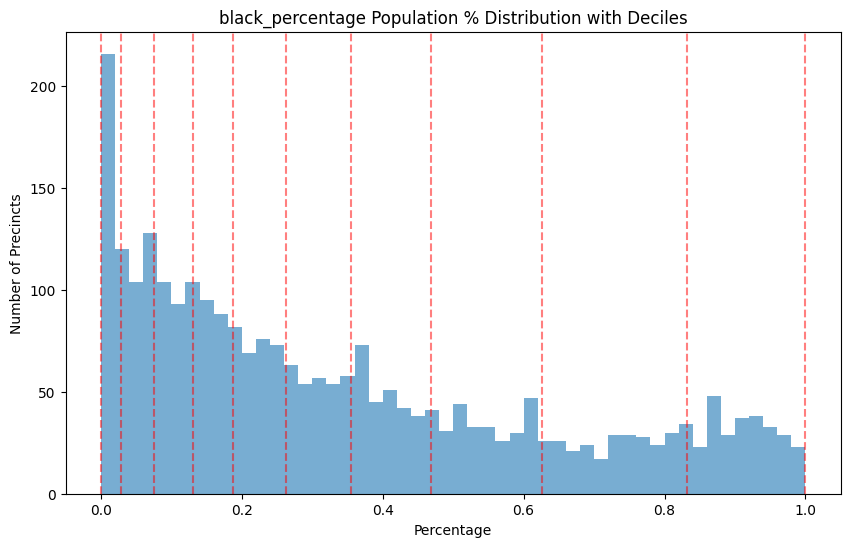

0.0    0.000000
0.1    0.003390
0.2    0.012340
0.3    0.020319
0.4    0.029578
0.5    0.039087
0.6    0.051013
0.7    0.064356
0.8    0.082740
0.9    0.118126
1.0    0.690579
Name: latino_percentage, dtype: float64


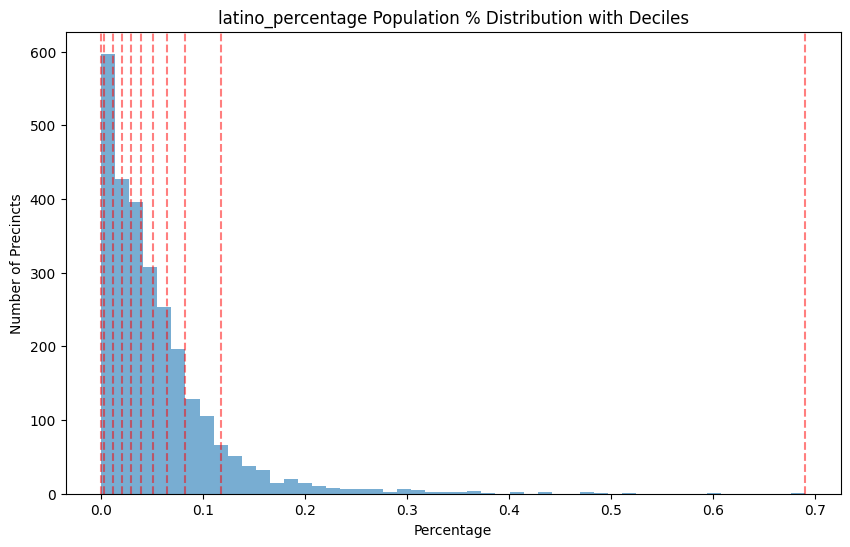

0.0    0.000000
0.1    0.006947
0.2    0.015059
0.3    0.022070
0.4    0.029371
0.5    0.038297
0.6    0.047609
0.7    0.060565
0.8    0.079479
0.9    0.122130
1.0    0.576372
Name: other_percentage, dtype: float64


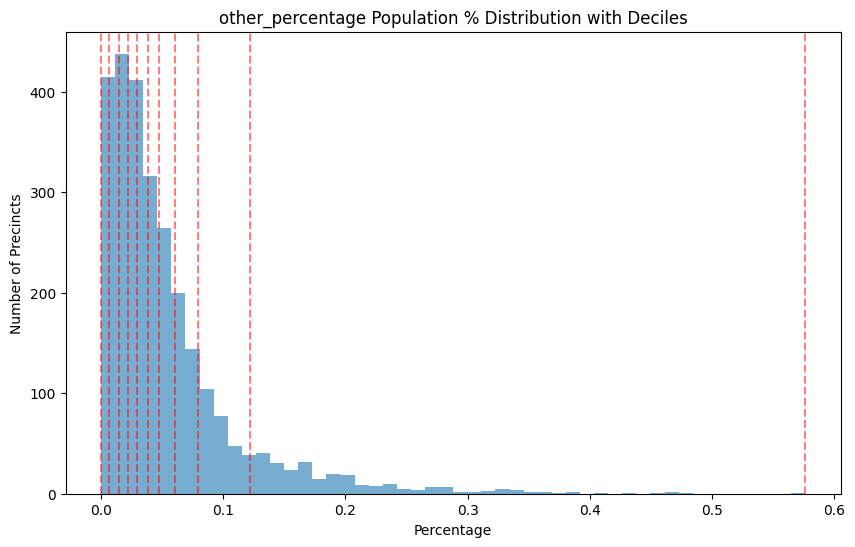

In [85]:
races = ['black_percentage', 'latino_percentage', 'other_percentage']
for col in races:
    values = demographic_precincts[col]
    if values.isna().sum() > 0:
        print(f"{col} has nan")
    deciles = demographic_precincts[col].quantile(np.linspace(0, 1, 11))
    print(deciles)

    plt.figure(figsize=(10,6))

    plt.hist(values, bins=50, alpha=0.6)

    # draw vertical lines for deciles
    for d in deciles:
        plt.axvline(d, color="red", linestyle="--", alpha=0.5)

    plt.title(f"{col} Population % Distribution with Deciles")
    plt.xlabel("Percentage")
    plt.ylabel("Number of Precincts")
    plt.show()

In [86]:
values.isna().sum()

np.int64(0)

In [105]:
import mapclassify
races = ['black', 'latino', 'other']
legend = {}
for race in races:
    values = np.log1p(demographic_precincts[f"{race}_percentage"])
    classifier = mapclassify.Quantiles(values, k=6)
    demographic_precincts[f"{race}_bin"] = classifier.yb
    legend[race] = {
        "bins": classifier.bins.tolist(),
        "min": float(values.min()),
        "max": float(values.max())
    }
    print(f"{race} bins: {classifier.bins}")
    
legend


black bins: [0.0603877  0.13853208 0.23352265 0.35247232 0.52967669 0.6931453 ]
latino bins: [0.00947395 0.02299187 0.0383424  0.05798402 0.08815154 0.52507128]
other bins: [0.01235327 0.0241348  0.03758146 0.05394822 0.08419206 0.45512617]


{'black': {'bins': [0.060387699213369075,
   0.1385320817752309,
   0.23352265326841748,
   0.35247231522431244,
   0.5296766867494889,
   0.6931453015046899],
  'min': 0.0,
  'max': 0.6931453015046899},
 'latino': {'bins': [0.009473953665960887,
   0.022991871043165715,
   0.03834239665119149,
   0.05798401655075049,
   0.08815153655952457,
   0.5250712771555288],
  'min': 0.0,
  'max': 0.5250712771555288},
 'other': {'bins': [0.012353267408680944,
   0.024134800576050094,
   0.03758145978217894,
   0.053948217190420145,
   0.08419205676306926,
   0.4551261696751362],
  'min': 0.0,
  'max': 0.4551261696751362}}

In [ ]:
import json
with open("Georgia/Georgia_legend.json", "w") as f:
    json.dump(legend, f)

In [102]:
demographic_precincts.head()

,precinct,total_population,white_percentage,black_percentage,latino_percentage,other_percentage,geometry,bin,black_bin,latino_bin,other_bin
0,Precinct APPLING-:-1B,1235.821148,0.869233,0.083331,0.044508,0.002928,"POLYGON ((-82.31535 31.94637, -82.31508 31.946...",0,1,3,0
1,Precinct APPLING-:-1C,1735.587191,0.686749,0.272342,0.024365,0.016544,"POLYGON ((-82.28215 31.85023, -82.28213 31.848...",0,3,2,1
2,Precinct APPLING-:-2,2153.287850,0.573826,0.366056,0.044978,0.015140,"POLYGON ((-82.26833 31.85442, -82.2672 31.8550...",0,3,3,1
3,Precinct APPLING-:-3A1,981.237529,0.719034,0.123757,0.149234,0.007975,"POLYGON ((-82.29315 31.94072, -82.29334 31.940...",0,1,5,0
4,Precinct APPLING-:-3C,1961.703292,0.727905,0.212156,0.029293,0.030646,"POLYGON ((-82.19986 31.81096, -82.19946 31.810...",1,2,2,2


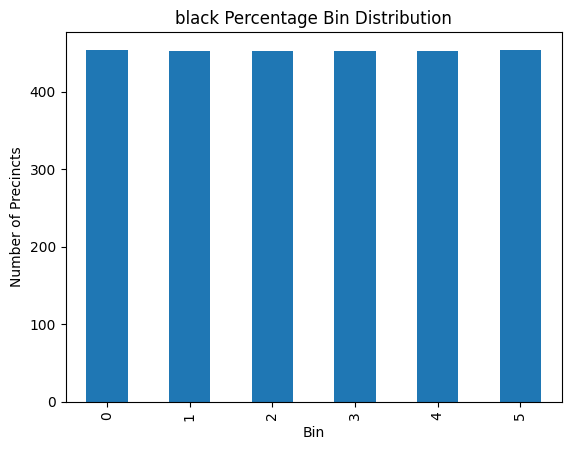

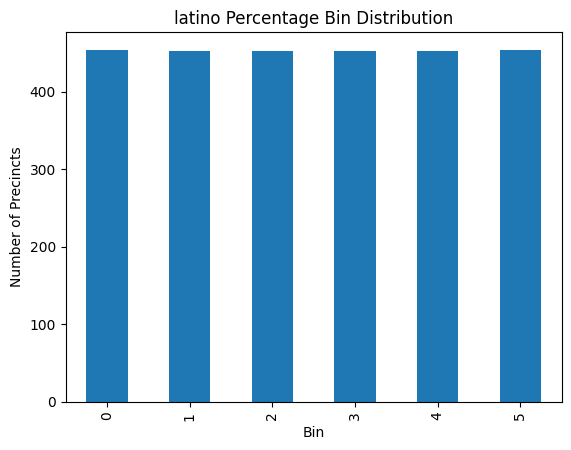

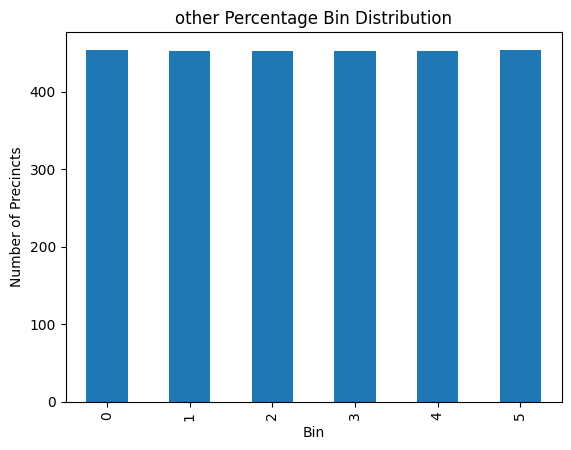

In [103]:
for race in races:
    demographic_precincts[f"{race}_bin"].value_counts().sort_index().plot(kind="bar")

    plt.title(f"{race} Percentage Bin Distribution")
    plt.xlabel("Bin")
    plt.ylabel("Number of Precincts")
    plt.show()

In [104]:
import topojson as tp
topo = tp.Topology(demographic_precincts, prequantize=True)
topo.to_json("Georgia/Georgia_precincts_topo.topojson")

### Congressional District

In [ ]:
zip_path = "../data/Georgia/GA_congressional.zip"

congressional_df = gpd.read_file(
    f"zip://{zip_path}!Congress-2023 shape.shp"
)
print(congressional_df.shape)
congressional_df.head()

In [ ]:
congression_col = congressional_df.columns
print(congression_col)


In [ ]:
filtered_congression_col = [x for x in congression_col if '18' not in x and 'F_' not in x and 'AP' not in x]
filtered_congression_col
remove = ['DEVIATION', 'IDEAL_VALU', 'DISTRICT_L']
filtered_congression_col = [x for x in filtered_congression_col if x not in remove]
filtered_congression_col

In [ ]:
filtered_congression_df = congressional_df[filtered_congression_col]
print(filtered_congression_df.shape)
filtered_congression_df.head()

In [ ]:
dict_race = {'NH_WHT': 'White', 'NH_BLK': 'Black', 'HISPANIC_O': 'Latino', 'POPULATION': 'Total Population', 'DISTRICT': 'District'}
filtered_congression_df = filtered_congression_df.rename(columns=dict_race)
filtered_congression_df.head()

In [ ]:
others_col = ['NH_ASN', 'NH_IND', 'NH_HWN', 'NH_OTH','NH_2_RACES']
filtered_congression_df['Other'] = filtered_congression_df[others_col].sum(axis=1)
filtered_congression_df = filtered_congression_df.drop(columns=others_col)
filtered_congression_df

In [ ]:
print(filtered_congression_df.columns)

In [ ]:
filtered_congression_df["District"] = filtered_congression_df["District"].astype(int)
filtered_congression_df

#### congressional demographic

In [ ]:
congressional_demographic_col = ['District', 'Total Population', 'White', 'Black', 'Latino', 'Other']
congressional_demographic_df = (filtered_congression_df[congressional_demographic_col].sort_values(by='District'))
congressional_demographic_df.head()

In [ ]:
congressional_demographic_df.to_csv("georgia/congressional_demographic.csv", index=False)

In [ ]:
total_others = congressional_demographic_df['Other'].sum()
total_white = congressional_demographic_df['White'].sum()
total_black = congressional_demographic_df['Black'].sum()
total_latino = congressional_demographic_df['Latino'].sum()
print(f"total other: {total_others}, white: {total_white}, black: {total_black}, latino: {total_latino}")

#### congressional boundaries

In [ ]:
congresional_boundaries_col = ['District', 'geometry']
congressional_boundaries_df = (
    filtered_congression_df[congresional_boundaries_col]
    .sort_values(by='District')
)

congressional_boundaries_df.head()

In [ ]:
congressional_boundaries_df.to_csv("georgia/congressional_boundaries.csv", index=False)

### Enacted plan on current precicnts

In [ ]:
print(type(final_precincts))
print(type(congressional_boundaries_df))

In [ ]:
congressional_boundaries_df = congressional_boundaries_df.to_crs(final_precincts.crs)
congressional_boundaries_df['geometry']

In [ ]:
print(final_precincts.shape)

In [ ]:
overlay = gpd.overlay(
    final_precincts,
    congressional_boundaries_df[['District', 'geometry']],
    how='intersection'
)

In [ ]:
overlay["intersect_area"] = overlay.geometry.area

In [ ]:
best = overlay.loc[
    overlay.groupby("UNIQUE_ID")["intersect_area"].idxmax()
]

In [ ]:
final_assignment = best[["UNIQUE_ID", "District"]].copy()

In [ ]:
precincts_with_districts = final_precincts.merge(
    final_assignment,
    on="UNIQUE_ID",
    how="left"
)

In [ ]:
print(precincts_with_districts.shape)
print(precincts_with_districts['District'].isna().sum())

In [ ]:
precincts_with_districts.head()

In [ ]:
precincts_with_districts['District'].unique()

In [ ]:
precincts_with_districts.to_file("Georgia/seawulf_district.gpkg", driver="GPKG")

In [ ]:
precincts_with_districts.plot(
    column="District",
    figsize=(5, 5),
    legend=True
)

### GerryChain

In [ ]:
import libpysal
from gerrychain import Graph
from gerrychain import (Partition, Graph, MarkovChain,
                        updaters, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from functools import partial

import random
import networkx as nx
random.seed(2024)

In [ ]:
gdf = gpd.read_file("Georgia/seawulf_district.gpkg")
graph = Graph.from_geodataframe(
    gdf,
    adjacency='queen'
)
G = graph
print(nx.is_connected(G))

In [ ]:
node = list(graph.nodes)[0]
print(graph.nodes[node])

In [ ]:
print(sum(graph.nodes[n]["Total_population"] for n in graph.nodes))

print(len(graph.nodes))

In [ ]:
print(gdf.columns)

In [ ]:
my_updaters = {
    "population": updaters.Tally("Total_population", alias='population'),
    "cut_edges": updaters.cut_edges
}

initial_partition = Partition(
    graph,
    assignment="District",
    updaters=my_updaters
)

In [ ]:
gdf.geometry.apply(lambda x: x.geom_type).value_counts()

In [ ]:
constraints.contiguous(initial_partition)

In [ ]:
from gerrychain import constraints

for d in initial_partition.parts:
    part = initial_partition.parts[d]
    if not nx.is_connected(graph.subgraph(part)):
        print("Broken district:", d)

In [ ]:
district3_nodes = list(initial_partition.parts[3])
gdf[gdf.index.isin(district3_nodes)].plot()

In [ ]:
components = list(nx.connected_components(graph.subgraph(district3_nodes)))

for i, comp in enumerate(components):
    print(f"Component {i} size:", len(comp))
    
largest = max(components, key=len)
island = [c for c in components if c != largest][0]

print("Island nodes:", island)

In [ ]:
gdf.loc[list(island)].plot()

In [ ]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2
)

In [ ]:
recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=40
)

In [ ]:
district_plans = []

for i, plan in enumerate(recom_chain):
    print(f"Finished step {i+1}/{len(recom_chain)}", end="\r")
    district_plans.append(plan.assignment)